In [1]:
import numpy as np
import matplotlib.pyplot as plt
import ellc
import edmcmc as edm
import batman
import corner
import pandas as pd
from matplotlib import gridspec
from matplotlib.pyplot import cm
from astropy.io import ascii


params = {
    "axes.labelsize": 18,
    "axes.labelpad": 9,
    "axes.titlesize": 20,
    "axes.linewidth": 2,
    "axes.labelweight": 3,
    "axes.titleweight": 3,
    "font.size": 15,
    "legend.fontsize": 15,
    "lines.linewidth": 2,
    "xtick.major.width": 2,
    "xtick.minor.width": 1,
    "xtick.major.size": 8,
    "xtick.minor.size": 5,
    "xtick.major.pad": 5,
    "xtick.labelsize": 15,
    "xtick.minor.visible": True,
    "xtick.direction": "in",
    "xtick.top": True,
    "ytick.major.width": 2,
    "ytick.minor.width": 1,
    "ytick.major.size": 8,
    "ytick.minor.size": 5,
    "ytick.major.pad": 7,
    "ytick.labelsize": 15,
    "ytick.minor.visible": True,
    "ytick.direction": "in",
    "ytick.right": True,
    "legend.frameon": True,
    "legend.loc": "upper right",
    #'text.usetex': True,
    #'text.latex.preamble': '\usepackage{helvet}\usepackage[T1]{fontenc}\usepackage{sfmath}',
    #'font.sans-serif': "Helvetica",
    #'font.family': "sans-serif",
    "ps.usedistiller": "xpdf",
    "savefig.dpi": 300,
    "figure.figsize": [7, 7],
}

plt.rcParams.update(params)

In [3]:
#flatchains = ascii.read('second_event_combined_flatchains.csv')
file = np.load('first_event_chains_25000_vsini.npz')
samples = file['thinflatchains']

labels=["a_over_R", "radius_planet", "vsini", "obliquity", "t0_trans", "incl", "period", 'fs', 'fc', 'c1', 'c2', 'slope', 'intercept']

directory = '/home/nadja/Documents/UWMadison/Research/TOI5082/'

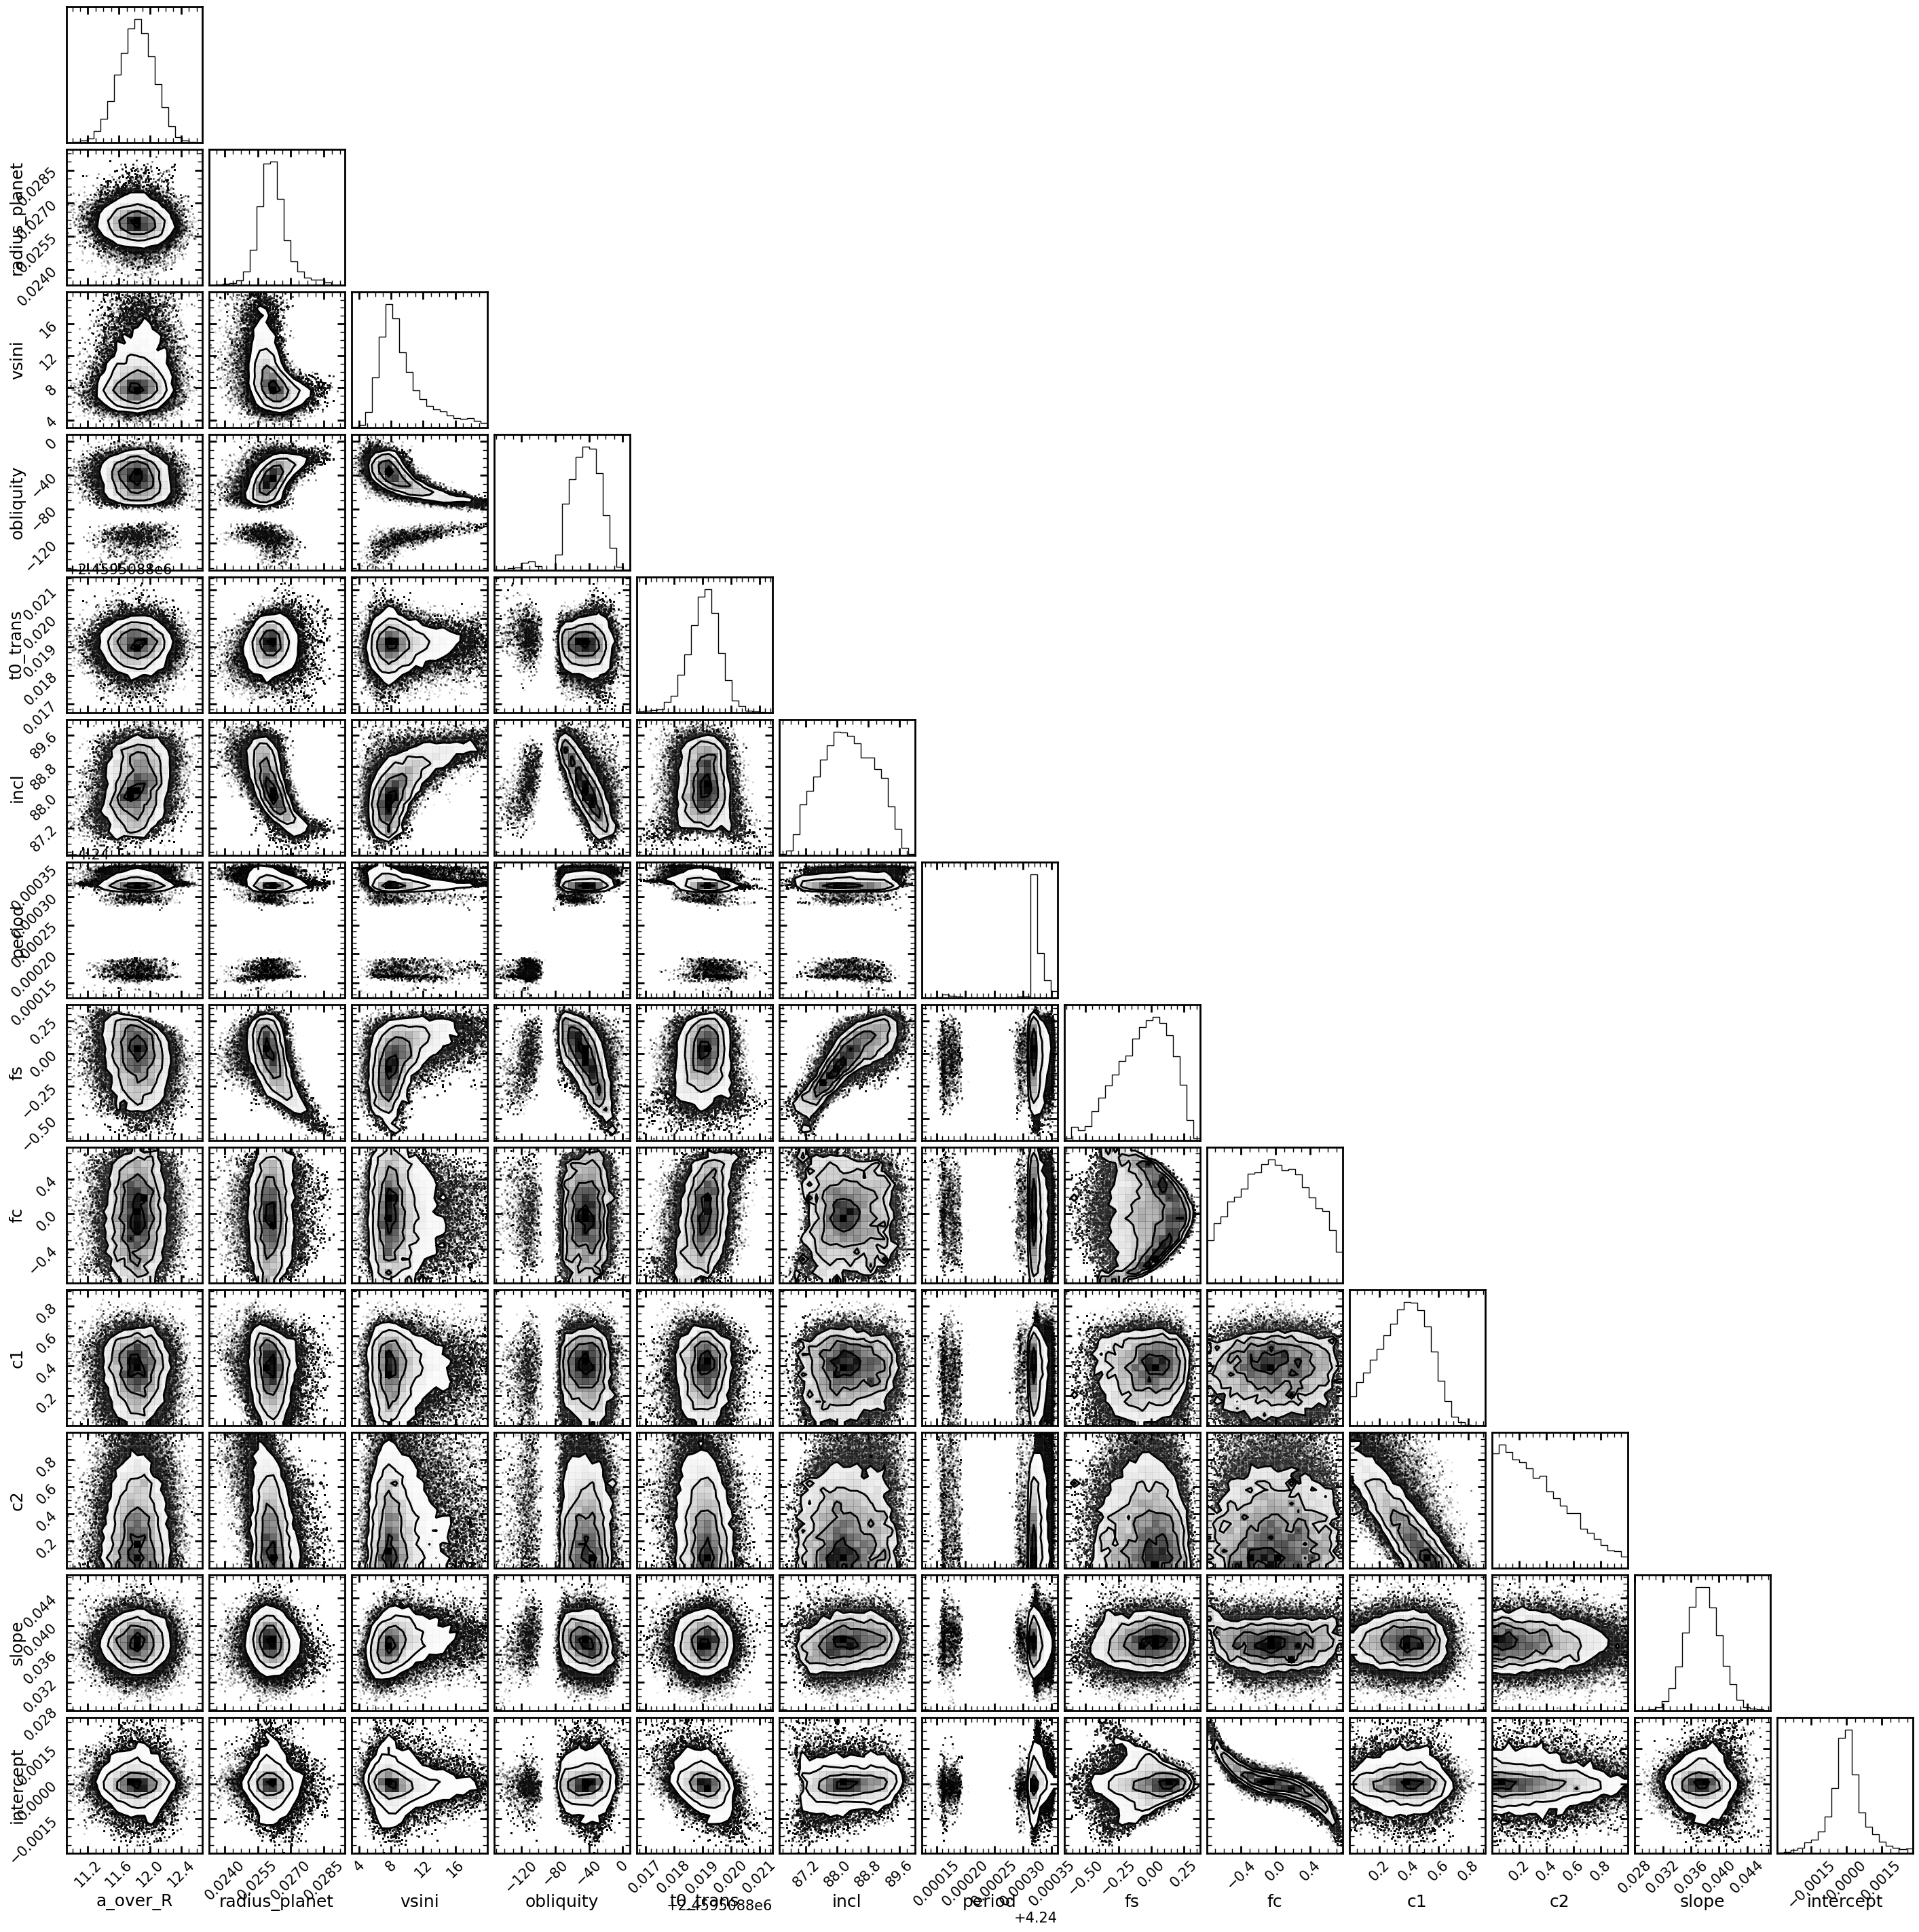

In [ ]:
corner.corner(
    samples,
    labels=["a_over_R", "radius_planet", "vsini", "obliquity", "t0_trans", "incl", "period", 'fs', 'fc', 'c1', 'c2', 'slope', 'intercept'],
)
plt.savefig(directory+'/first_event/second_event_25000_thinsamples.png')
plt.show()


In [ ]:
print(samples.shape)

In [3]:
def unpack_file(filepath):
    df = pd.read_csv(filepath, comment="#")
    for col in ("ccfjdsum", "ccfrvmod", "dvrms"):
        if col not in df.columns:
            raise ValueError(f"Input CSV missing required column: {col}")

    time_rv = df["ccfjdsum"].values.astype(float)  # times in days
    data_rv = df["ccfrvmod"].values.astype(float)  # observed RV in km/s
    err_rv = df["dvrms"].values.astype(float)  # RV uncertainties in km/s
    
    data_rv -= np.median(data_rv)
    return time_rv, data_rv, err_rv

second_rv = ("/home/nadja/Documents/UWMadison/Research/TOI5082/2026-01-20_TOI5082.csv")
time_obs_2, rv_data_2, rv_err_2 = unpack_file(second_rv)
print(rv_data_2)

[ 0.0055  0.0027  0.0025  0.0028  0.0031  0.0014  0.0005  0.0008  0.0003
 -0.0003 -0.0013 -0.002  -0.0022 -0.0013  0.0006  0.0006  0.0011  0.0014
 -0.0021 -0.0029 -0.0045 -0.0056 -0.0049 -0.0056 -0.0057 -0.007 ]


In [4]:
def sma_star_units(sma, rstar):
    return (sma*rstar) #rstar in units of Rsun
#initial guesses
t0_bjd = 2459508.8190741274
rp_rs = (10 ** (-3) * 0.93**2) ** 0.5  # stellar radius units
sma = 11.8  #RATIO
RSTAR = 0.93
a_calc = sma_star_units(sma, RSTAR)
vsini = 1.75
lambda_guess = 0
incl = 87
r_1 = 1 / sma
r_2 = rp_rs * r_1
orbital_period = 4.2403567  # orbital_period
q_guess = 0.00002109

shape = 'sphere'
e_val = 0
periastron = 90
coef_1 = 0.1
coef_2 = 0.3

In [5]:
#systemic offset
i_rad = np.radians(incl)
rsum = (r_1 + r_2)
val = rsum / max(1e-12, np.sin(i_rad))
if val >= 1.0:
    transit_duration_days = 0.2
else:
    transit_duration_days = orbital_period / np.pi * val

transit_half_phase = (transit_duration_days / 2.0) / orbital_period
phases_for_mask = ((time_obs_2 - t0_bjd) / orbital_period + 0.5) % 1.0 - 0.5 #change
in_transit_mask = np.abs(phases_for_mask) < transit_half_phase
out_of_transit_mask = ~in_transit_mask

if out_of_transit_mask.sum() < 3:
    out_of_transit_mask = np.ones_like(out_of_transit_mask, dtype=bool)
weights = 1.0 / (rv_err_2**2) #change

gamma_weighted = np.sum(weights[out_of_transit_mask] * rv_data_2[out_of_transit_mask]) / np.sum(weights[out_of_transit_mask]) #change
rv_data_2 = rv_data_2 - gamma_weighted #change

In [6]:
def rv_function(aR_guess, rp_guess, vsini_guess, obliq_guess, incl_guess, t0_guess, period, fs, fc, c1,c2, timeArr):
    t0_rv_guess = t0_guess #change
    rv_model = ellc.rv(
        timeArr,
        t_zero=t0_rv_guess,
        period=period,
        lambda_1=obliq_guess,
        radius_1 = 1/aR_guess,
        radius_2= rp_guess * (1/aR_guess),
        incl=incl_guess,
        a=aR_guess,
        f_c=fc,
        f_s=fs,
        shape_1="sphere",
        shape_2="sphere",
        sbratio=0,
        vsini_1=vsini_guess,
        flux_weighted=True,
        q=0.00002109,
        ldc_1 = [c1,c2],
        ld_1='quad'
    )
    rv_model = np.asarray(rv_model[0])
    return rv_model

t0_bjd = 2459508.8190817493
best_period = 4.240323127757444
time_centered_1 = time_obs_2 - np.median(time_obs_2)

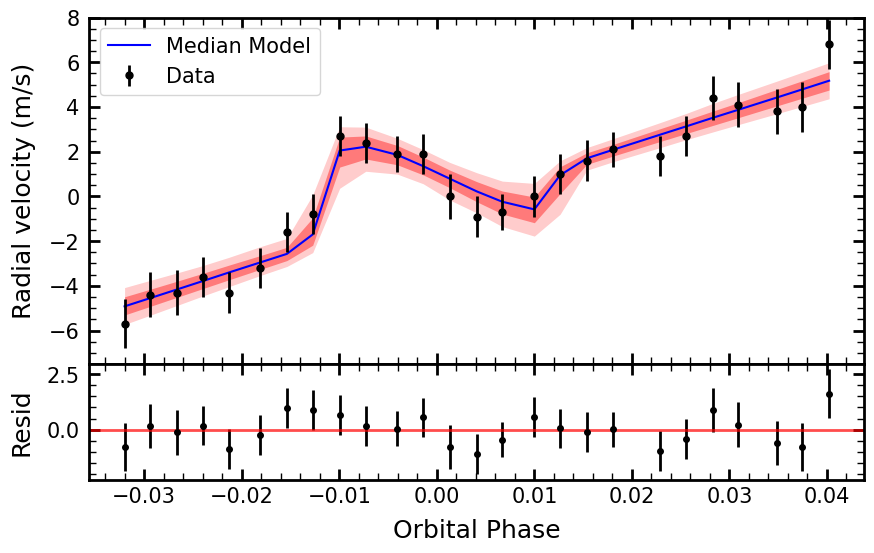

In [9]:
phase_rv = ((time_obs_2 - t0_bjd) / best_period) - np.round(
    (time_obs_2 - t0_bjd) / best_period)
#change
def unpack_params(arr):
    a_R = arr[0]
    rp = arr[1]
    vsini = arr[2]
    obliq = arr[3]
    t0 = arr[4]
    incl = arr[5]
    per = arr[6]
    f_s = arr[7]
    f_c = arr[8]
    c1 = arr[9]    
    c2 = arr[10]   
    slope = arr[11]
    intercept = arr[12]
    return a_R, rp, vsini, obliq, incl, t0, per, f_s, f_c, c1, c2, slope, intercept

# Posterior models compilation step
samples_for_outputs = samples

# aR_guess, rp_guess, vsini_guess, obliq_guess, incl_guess, t0_guess, period, fs, fc, c1,c2, timeArr

# Posterior bands
all_samples = samples_for_outputs
nsamples_total = all_samples.shape[0]
nsamp = min(1000, nsamples_total)
sel_idx = np.linspace(0, nsamples_total - 1, nsamp, dtype=int)

ntime = len(time_obs_2) #change
models = np.zeros((nsamp, ntime))

for j, idx in enumerate(sel_idx):
    unpacked = unpack_params(all_samples[idx, :])
    if unpacked is None:
        models[j, :] = np.nan
        continue
    
    (a_over_s, rp_s, vsini_s, lambda_s, inc_s, t0_bjd_s, 
     per_s, fs_s, fc_s, ld1, ld2, slope_s, intercept_s) = unpacked
    
    #RV from ellc (no bg)
    pure_rv = rv_function(a_over_s, rp_s, vsini_s, lambda_s, inc_s, t0_bjd_s, per_s, fs_s, fc_s, ld1, ld2, time_obs_2) #change
    
    #injecting the bg trend.
    models[j, :] = pure_rv + (slope_s * time_centered_1 + intercept_s)

# Track statistical distribution slices across models
median_model = np.nanmedian(models, axis=0)
p16 = np.nanpercentile(models, 16.0, axis=0)
p84 = np.nanpercentile(models, 84.0, axis=0)
p025 = np.nanpercentile(models, 2.5, axis=0)
p975 = np.nanpercentile(models, 97.5, axis=0)

#plotting
fig3 = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(nrows=2, ncols=1, figure=fig3, hspace=0.0, height_ratios=[3, 1])

ax3 = plt.subplot(gs[0, 0])
# Plot data points in phase coordinate space
ax3.errorbar(phase_rv, rv_data_2 * 1e3, yerr=rv_err_2 * 1e3, fmt="o", ms=5, c="k", label="Data", zorder=5)

sort_index = np.argsort(phase_rv)
phase_sorted = phase_rv[sort_index]
model_sorted = median_model[sort_index]
p025_sorted = p025[sort_index]
p975_sorted = p975[sort_index]
p16_sorted = p16[sort_index]
p84_sorted = p84[sort_index]

# Plot corrected line
ax3.plot(phase_sorted, model_sorted * 1e3, "-", lw=1.5, c="blue", label='Median Model', zorder=4)

#1-sig, 2-sig contours
ax3.fill_between(phase_sorted, p025_sorted * 1e3, p975_sorted * 1e3, color='red', alpha=0.2, linewidth=0.0)
ax3.fill_between(phase_sorted, p16_sorted * 1e3, p84_sorted * 1e3, color='red', alpha=0.4, linewidth=0.0)

ax3.set_ylabel("Radial velocity (m/s)", color="black")
ax3.set_ylim(-7.499, 8)
ax3.legend(loc='upper left')

#Residuals
residuals_ms = (rv_data_2 - median_model) * 1e3
ax_bot = plt.subplot(gs[1, 0], sharex=ax3)
ax_bot.errorbar(phase_rv, residuals_ms, yerr=rv_err_2 * 1e3, fmt="o", c="k", ms=4)
ax_bot.axhline(0.0, color="red", alpha=0.7)
ax_bot.set_xlabel("Orbital Phase", color="black")
ax_bot.set_ylabel("Resid", color="black")

plt.savefig('toi5082_rv_second_event_25000.png')

In [8]:
tags = ['a/R', 'Rp/Rs', 'vsini', 'obliquity', 't0_trans', 'incl', 'period', "fs", "fc", "c1", "c2", 'a', 'c']
color=cm.viridis(np.linspace(0,1,len(chains[:,0,0])))

fig6 = plt.figure(figsize=(10, 2 * len(chains[0,0,:])))
gs_6 = gridspec.GridSpec(
    nrows=len(chains[0,0,:]), ncols=1, figure=fig6, hspace=None, wspace=None)

print(chains.shape)
for i in range(len(chains[0,0,:])):
    ax5=plt.subplot(gs_6[i, 0])
    for j in range(len(chains[:,0,0])):
        ax5.plot(links, chains[j,:,i], color=color[j])
    if i == (len(chains[0,0,:])) - 1:
        ax5.set_xlabel('Link number')
    else:
        ax5.set_xticklabels([])
    ax5.set_ylabel(tags[i])

plt.tight_layout()
fig6.subplots_adjust(hspace=0)
plt.savefig('trace_plot_second_event_NEW.png')


NameError: name 'chains' is not defined

In [ ]:
c = ['red', 'green', 'blue', 'purple', 'black', 'brown', 'orange', 'pink', 'lime', 'cyan', "gray", 'olive', 'red']

fig6 = plt.figure(figsize=(10, 2 * len(p0)))
gs_6 = gridspec.GridSpec(
    nrows=len(p0), ncols=1, figure=fig6, hspace=None, wspace=None)

for i in range(len(p0)):
    ax5=plt.subplot(gs_6[i, 0])
    ax5.plot(out.whichwalker, out.flatchains[:,i], color=c[i])
    if i == len(p0) - 1:
        ax5.set_xlabel('Walker number')
    else:
        ax5.set_xticklabels([])
    ax5.set_ylabel(tags[i])

plt.tight_layout()
fig6.subplots_adjust(hspace=0)

plt.savefig('secondevent_walker_v_param.png')
plt.show()